<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/21025_genders_IOP_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/IOP study.xlsx')

In [ ]:
df.shape

(133, 21)

In [ ]:
df.columns

Index(['Name ', 'Id ', 'post op date', 'Age ', 'Male', 'Female', 'RE IOP',
       'LE IOP', 'RE (Post)', 'LE (Post)', 'Fellow eye', 'In the bag ',
       'In the sulcus', 'IOP-RE(6th wk)', 'IOP-LE(6th wk)', 'CCT-RE(6th wk)',
       'CCT-LE(6th wk)', 'LV-RE(6th week)', 'LV-LE(6th week)',
       'mature cataract', 'Hyphema'],
      dtype='object')

In [ ]:
df_sheets = pd.ExcelFile('/content/drive/MyDrive/IOP study.xlsx')
df_sheets.sheet_names

['Original data',
 'filter processing sheet',
 'Filtered data males',
 'Filtered data females',
 'males RE data',
 'males LE data',
 'females RE data',
 'females LE data',
 'males bag data',
 'males sulcus data',
 'females bag data',
 'females sulcus data',
 'arranged data']

In [ ]:
arrangedata = df_sheets.parse('arranged data')
arrangedata

,Patient,Age,Gender,Operated eye,IOP,Fixation
0,Chamamma,72,f,OS,9,s
1,Vanajakshi,65,f,OS,12,s
2,Hanumamma,87,f,OS,11,s
3,Padmamma,68,f,OS,11,b
4,Puttaiah,62,m,OS,10,b
...,...,...,...,...,...,...
128,Rathnamma,63,f,OD,9,b
129,mahadevamma,76,m,OS,12,s
130,shivakumar,75,m,OD,34,b
131,kempamma,55,f,OS,11,s


In [ ]:
arrangedata.shape

(133, 6)

In [ ]:
arrangedata.columns

Index(['Patient', 'Age ', 'Gender', 'Operated eye', 'IOP', 'Fixation '], dtype='object')

In [ ]:
arrangedata.isnull().sum()

,0
Patient,5
Age,0
Gender,0
Operated eye,0
IOP,0
Fixation,0


In [ ]:
arrangedata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Patient       128 non-null    object
 1   Age           133 non-null    int64 
 2   Gender        133 non-null    object
 3   Operated eye  133 non-null    object
 4   IOP           133 non-null    int64 
 5   Fixation      133 non-null    object
dtypes: int64(2), object(4)
memory usage: 6.4+ KB


In [ ]:
arrangedata.describe()

,Age,IOP
count,133.000000,133.00000
mean,66.578947,15.81203
std,10.702740,8.79062
min,40.000000,1.00000
25%,60.000000,11.00000
50%,68.000000,13.00000
75%,74.000000,17.00000
max,88.000000,53.00000


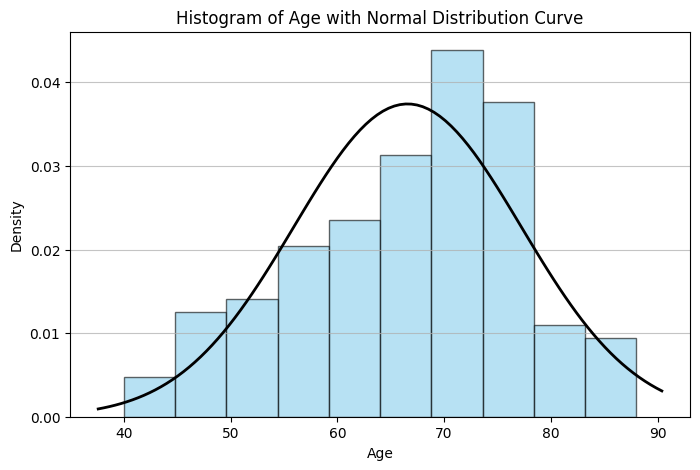

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

# Create histogram for Age
plt.figure(figsize=(8, 5))
plt.hist(arrangedata['Age '], bins=10, density=True, alpha=0.6, color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Age with Normal Distribution Curve')
plt.xlabel('Age')
plt.ylabel('Density')

# Add a normal distribution curve
mu, std = norm.fit(arrangedata['Age '])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

# Show grid
plt.grid(axis='y', alpha=0.75)

# Display plot
plt.show()

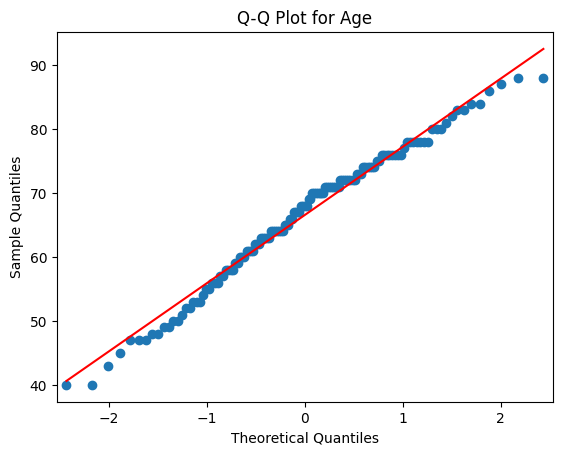

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Create Q-Q plot for 'Age ' column
sm.qqplot(arrangedata['Age '], line='s')
plt.title('Q-Q Plot for Age')
plt.show()

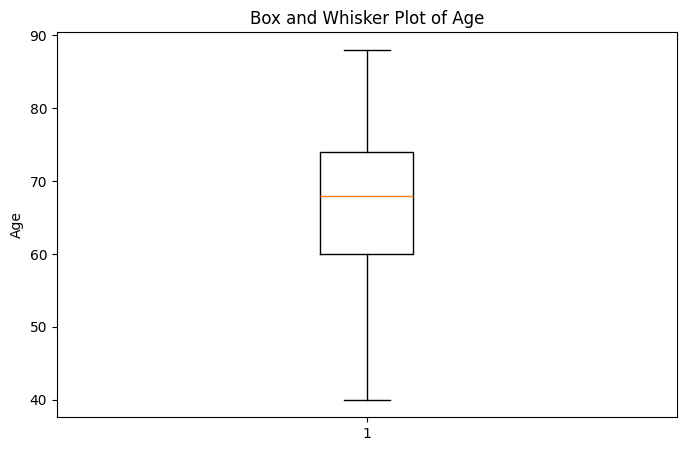

In [ ]:
import matplotlib.pyplot as plt

# Create a box and whisker plot for Age
plt.figure(figsize=(8, 5))
plt.boxplot(arrangedata['Age '])

# Add titles and labels
plt.title('Box and Whisker Plot of Age')
plt.ylabel('Age')

# Display the plot
plt.show()

In [ ]:
from scipy.stats import shapiro

# Perform Shapiro-Wilk test on 'Age ' column
shapiro_test = shapiro(arrangedata['Age '])
print(f"Shapiro-Wilk test on Age:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")

# Interpret the result
alpha = 0.05
if shapiro_test.pvalue > alpha:
    print("The data appears to be normally distributed (fail to reject H0)")
else:
    print("The data does not appear to be normally distributed (reject H0)")

Shapiro-Wilk test on Age:
Statistic: 0.980940095611843
p-value: 0.05904109701426234
The data appears to be normally distributed (fail to reject H0)


In [ ]:
# Descriptive statistics for Age by Gender
descriptive_stats_age_by_gender = arrangedata.groupby('Gender')['Age '].describe()
display(descriptive_stats_age_by_gender)

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
f,71.0,67.070423,11.139792,40.0,61.00,68.0,75.5,88.0
m,62.0,66.016129,10.240537,45.0,58.25,67.5,73.5,88.0


In [ ]:
arrangedata.columns

Index(['Patient', 'Age ', 'Gender', 'Operated eye', 'IOP', 'Fixation '], dtype='object')

In [ ]:
arrangedata['IOP'].describe()

,IOP
count,133.00000
mean,15.81203
std,8.79062
min,1.00000
25%,11.00000
50%,13.00000
75%,17.00000
max,53.00000


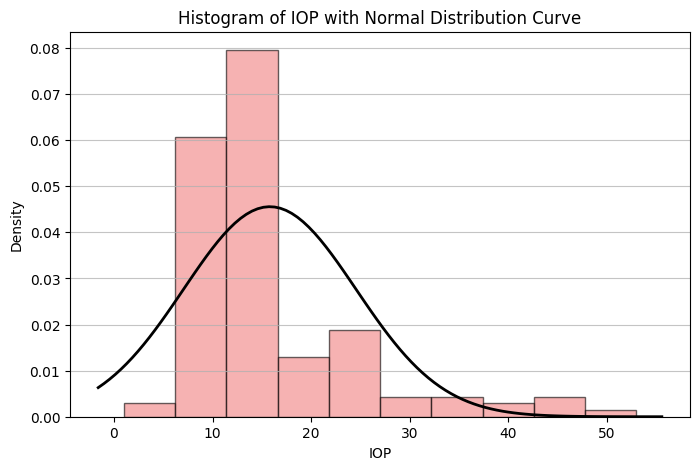

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

# Create histogram for IOP
plt.figure(figsize=(8, 5))
plt.hist(arrangedata['IOP'], bins=10, density=True, alpha=0.6, color='lightcoral', edgecolor='black')

# Add titles and labels
plt.title('Histogram of IOP with Normal Distribution Curve')
plt.xlabel('IOP')
plt.ylabel('Density')

# Add a normal distribution curve
mu, std = norm.fit(arrangedata['IOP'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

# Show grid
plt.grid(axis='y', alpha=0.75)

# Display plot
plt.show()

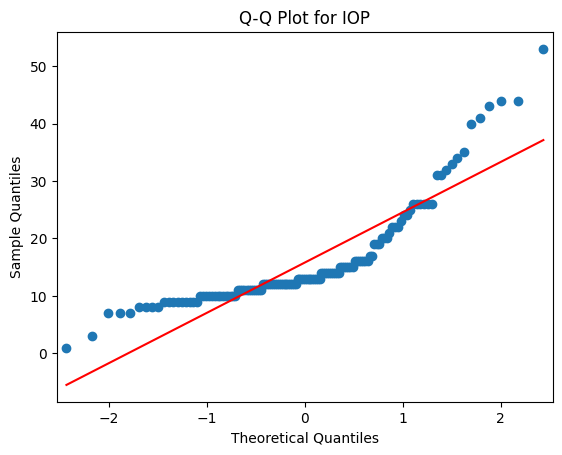

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Create Q-Q plot for 'IOP' column
sm.qqplot(arrangedata['IOP'], line='s')
plt.title('Q-Q Plot for IOP')
plt.show()

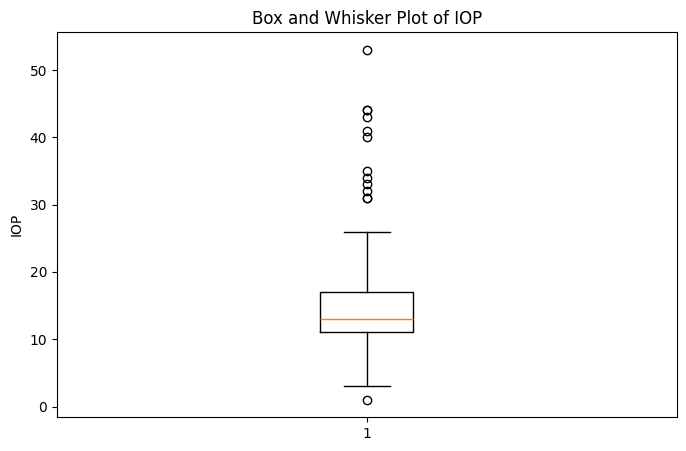

In [ ]:
import matplotlib.pyplot as plt

# Create a box and whisker plot for IOP
plt.figure(figsize=(8, 5))
plt.boxplot(arrangedata['IOP'])

# Add titles and labels
plt.title('Box and Whisker Plot of IOP')
plt.ylabel('IOP')

# Display the plot
plt.show()

In [ ]:
from scipy.stats import shapiro

# Perform Shapiro-Wilk test on 'IOP' column
shapiro_test = shapiro(arrangedata['IOP'])
print(f"Shapiro-Wilk test on IOP:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")

# Interpret the result
alpha = 0.05
if shapiro_test.pvalue > alpha:
    print("The data appears to be normally distributed (fail to reject H0)")
else:
    print("The data does not appear to be normally distributed (reject H0)")

Shapiro-Wilk test on IOP:
Statistic: 0.7907790613866759
p-value: 1.7014940134603348e-12
The data does not appear to be normally distributed (reject H0)


In [ ]:
from scipy.stats import ttest_ind

# Separate IOP data by Gender
group1_iop = arrangedata[arrangedata['Gender'] == 'm']['IOP']
group2_iop = arrangedata[arrangedata['Gender'] == 'f']['IOP']

# Perform independent samples t-test
ttest_result_iop = ttest_ind(group1_iop, group2_iop)

print(f"Independent Samples t-test on IOP based on Gender:")
print(f"Statistic: {ttest_result_iop.statistic}")
print(f"p-value: {ttest_result_iop.pvalue}")

# Interpret the result
alpha = 0.05
if ttest_result_iop.pvalue > alpha:
    print("There is no significant difference in IOP between the two gender groups (fail to reject H0)")
else:
    print("There is a significant difference in IOP between the two gender groups (reject H0)")

Independent Samples t-test on IOP based on Gender:
Statistic: 1.1013587793108208
p-value: 0.2727600364585547
There is no significant difference in IOP between the two gender groups (fail to reject H0)


In [ ]:
from scipy.stats import mannwhitneyu

# Separate Age data by Gender
group1_age = arrangedata[arrangedata['Gender'] == 'm']['Age ']
group2_age = arrangedata[arrangedata['Gender'] == 'f']['Age ']

# Perform Mann-Whitney U test
mannwhitneyu_result_age = mannwhitneyu(group1_age, group2_age)

print(f"Mann-Whitney U Test on Age based on Gender:")
print(f"Statistic: {mannwhitneyu_result_age.statistic}")
print(f"p-value: {mannwhitneyu_result_age.pvalue}")

# Interpret the result
alpha = 0.05
if mannwhitneyu_result_age.pvalue > alpha:
    print("There is no significant difference in Age between the two gender groups (fail to reject H0)")
else:
    print("There is a significant difference in Age between the two gender groups (reject H0)")

Mann-Whitney U Test on Age based on Gender:
Statistic: 2046.5
p-value: 0.48699508474936504
There is no significant difference in Age between the two gender groups (fail to reject H0)


In [ ]:
from scipy.stats import mannwhitneyu

# Separate IOP data by Gender
group1_iop = arrangedata[arrangedata['Gender'] == 'm']['IOP']
group2_iop = arrangedata[arrangedata['Gender'] == 'f']['IOP']

# Perform Mann-Whitney U test
mannwhitneyu_result_iop = mannwhitneyu(group1_iop, group2_iop)

print(f"Mann-Whitney U Test on IOP based on Gender:")
print(f"Statistic: {mannwhitneyu_result_iop.statistic}")
print(f"p-value: {mannwhitneyu_result_iop.pvalue}")

# Interpret the result
alpha = 0.05
if mannwhitneyu_result_iop.pvalue > alpha:
    print("There is no significant difference in IOP between the two gender groups (fail to reject H0)")
else:
    print("There is a significant difference in IOP between the two gender groups (reject H0)")

Mann-Whitney U Test on IOP based on Gender:
Statistic: 2470.5
p-value: 0.22351468502562044
There is no significant difference in IOP between the two gender groups (fail to reject H0)


In [ ]:
from scipy.stats import mannwhitneyu

# Separate IOP data by Operated eye
group1_iop_eye = arrangedata[arrangedata['Operated eye'] == 'OD']['IOP']
group2_iop_eye = arrangedata[arrangedata['Operated eye'] == 'OS']['IOP']

# Perform Mann-Whitney U test
mannwhitneyu_result_iop_eye = mannwhitneyu(group1_iop_eye, group2_iop_eye)

print(f"Mann-Whitney U Test on IOP based on Operated eye:")
print(f"Statistic: {mannwhitneyu_result_iop_eye.statistic}")
print(f"p-value: {mannwhitneyu_result_iop_eye.pvalue}")

# Interpret the result
alpha = 0.05
if mannwhitneyu_result_iop_eye.pvalue > alpha:
    print("There is no significant difference in IOP between the two operated eye groups (fail to reject H0)")
else:
    print("There is a significant difference in IOP between the two operated eye groups (reject H0)")

Mann-Whitney U Test on IOP based on Operated eye:
Statistic: 2315.5
p-value: 0.6386847287126876
There is no significant difference in IOP between the two operated eye groups (fail to reject H0)


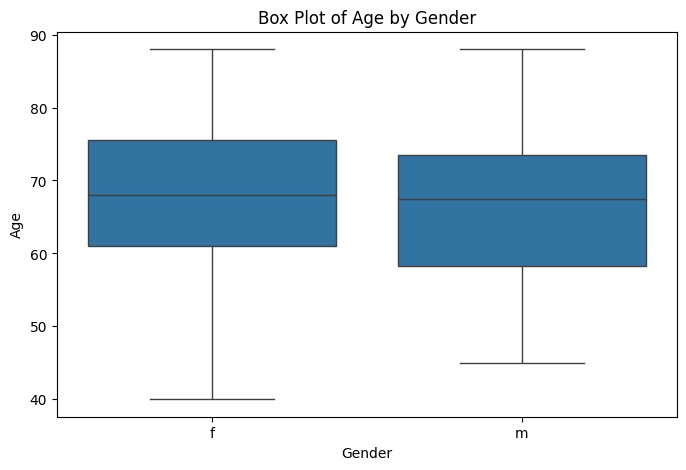

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plot for Age by Gender
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gender', y='Age ', data=arrangedata)
plt.title('Box Plot of Age by Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

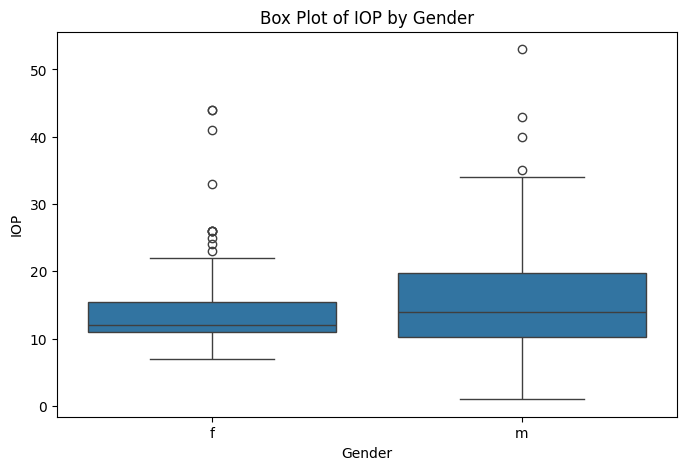

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plot for IOP by Gender
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gender', y='IOP', data=arrangedata)
plt.title('Box Plot of IOP by Gender')
plt.xlabel('Gender')
plt.ylabel('IOP')
plt.show()

In [ ]:
from scipy.stats import spearmanr

# Perform Spearman's rank correlation test
spearman_corr, spearman_pvalue = spearmanr(arrangedata['IOP'], arrangedata['Age '])

print(f"Spearman's Rank Correlation between IOP and Age:")
print(f"Correlation coefficient: {spearman_corr}")
print(f"p-value: {spearman_pvalue}")

# Interpret the result
alpha = 0.05
if spearman_pvalue > alpha:
    print("There is no significant monotonic relationship between IOP and Age (fail to reject H0)")
else:
    print("There is a significant monotonic relationship between IOP and Age (reject H0)")

Spearman's Rank Correlation between IOP and Age:
Correlation coefficient: -0.17509475733630342
p-value: 0.04381764063184083
There is a significant monotonic relationship between IOP and Age (reject H0)


In [ ]:
from scipy.stats import pearsonr

# Perform Pearson correlation test
pearson_corr, pearson_pvalue = pearsonr(arrangedata['IOP'], arrangedata['Age '])

print(f"Pearson Correlation between IOP and Age:")
print(f"Correlation coefficient: {pearson_corr}")
print(f"p-value: {pearson_pvalue}")

# Interpret the result (with caution due to potential normality violation)
alpha = 0.05
if pearson_pvalue > alpha:
    print("There is no significant linear relationship between IOP and Age (fail to reject H0)")
else:
    print("There is a significant linear relationship between IOP and Age (reject H0)")

Pearson Correlation between IOP and Age:
Correlation coefficient: -0.20207068945085807
p-value: 0.019673816193153174
There is a significant linear relationship between IOP and Age (reject H0)


In [ ]:
arrangedata['Operated eye'].value_counts()

,count
Operated eye,
OD,67
OS,66


In [ ]:
from scipy.stats import ttest_ind

# Separate Age data by Operated eye
group1_age_eye = arrangedata[arrangedata['Operated eye'] == 'OD']['Age ']
group2_age_eye = arrangedata[arrangedata['Operated eye'] == 'OS']['Age ']

# Perform independent samples t-test
ttest_result_age_eye = ttest_ind(group1_age_eye, group2_age_eye)

print(f"Independent Samples t-test on Age based on Operated eye:")
print(f"Statistic: {ttest_result_age_eye.statistic}")
print(f"p-value: {ttest_result_age_eye.pvalue}")

# Interpret the result
alpha = 0.05
if ttest_result_age_eye.pvalue > alpha:
    print("There is no significant difference in Age between the two operated eye groups (fail to reject H0)")
else:
    print("There is a significant difference in Age between the two operated eye groups (reject H0)")

Independent Samples t-test on Age based on Operated eye:
Statistic: -2.9113859886771207
p-value: 0.00423055786937336
There is a significant difference in Age between the two operated eye groups (reject H0)


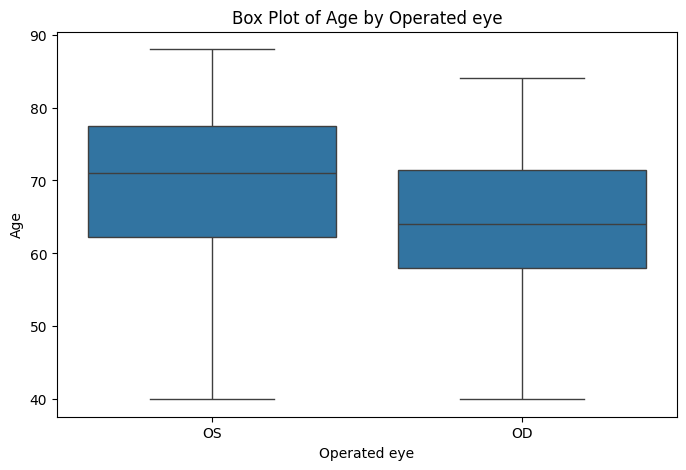

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plot for Age by Operated eye
plt.figure(figsize=(8, 5))
sns.boxplot(x='Operated eye', y='Age ', data=arrangedata)
plt.title('Box Plot of Age by Operated eye')
plt.xlabel('Operated eye')
plt.ylabel('Age')
plt.show()

In [40]:
from scipy.stats import mannwhitneyu

# Separate IOP data by Operated eye
group1_iop_eye = arrangedata[arrangedata['Operated eye'] == 'OD']['IOP']
group2_iop_eye = arrangedata[arrangedata['Operated eye'] == 'OS']['IOP']

# Perform Mann-Whitney U test
mannwhitneyu_result_iop_eye = mannwhitneyu(group1_iop_eye, group2_iop_eye)

print(f"Mann-Whitney U Test on IOP based on Operated eye:")
print(f"Statistic: {mannwhitneyu_result_iop_eye.statistic}")
print(f"p-value: {mannwhitneyu_result_iop_eye.pvalue}")

# Interpret the result
alpha = 0.05
if mannwhitneyu_result_iop_eye.pvalue > alpha:
    print("There is no significant difference in IOP between the two operated eye groups (fail to reject H0)")
else:
    print("There is a significant difference in IOP between the two operated eye groups (reject H0)")

Mann-Whitney U Test on IOP based on Operated eye:
Statistic: 2315.5
p-value: 0.6386847287126876
There is no significant difference in IOP between the two operated eye groups (fail to reject H0)


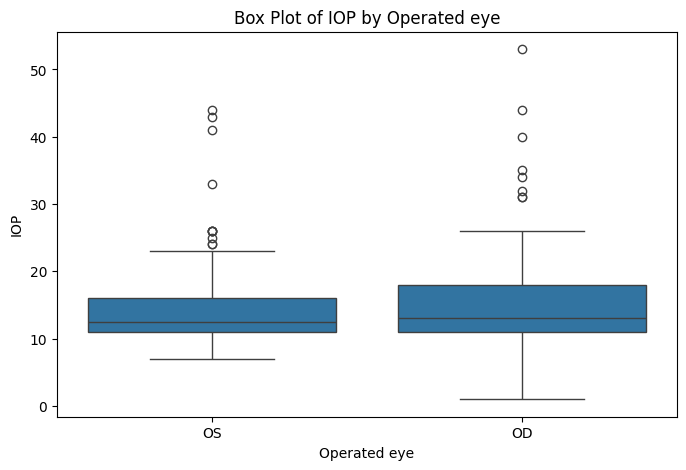

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plot for IOP by Operated eye
plt.figure(figsize=(8, 5))
sns.boxplot(x='Operated eye', y='IOP', data=arrangedata)
plt.title('Box Plot of IOP by Operated eye')
plt.xlabel('Operated eye')
plt.ylabel('IOP')
plt.show()

In [42]:
# Categorize Age into bins
# You can adjust the bins and labels as needed based on your data and analysis goals
age_bins = [arrangedata['Age '].min(), 50, 60, 70, 80, arrangedata['Age '].max()]
age_labels = ['40-50', '51-60', '61-70', '71-80', '81+']
arrangedata['Age_Category'] = pd.cut(arrangedata['Age '], bins=age_bins, labels=age_labels, right=False, include_lowest=True)

# Display the counts in each category to check the distribution
print("Counts of Age Categories:")
display(arrangedata['Age_Category'].value_counts())

Counts of Age Categories:


,count
Age_Category,
71-80,50
61-70,37
51-60,22
40-50,11
81+,11


In [43]:
from scipy.stats import chi2_contingency

# Create a contingency table of Age Category and Gender
contingency_table = pd.crosstab(arrangedata['Age_Category'], arrangedata['Gender'])
print("\nContingency Table of Age Category and Gender:")
display(contingency_table)

# Perform the Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Test of Association between Age Category and Gender:")
print(f"Chi-Square Statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies Table:")
display(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

# Interpret the result
alpha = 0.05
if p > alpha:
    print("\nThere is no significant association between Age Category and Gender (fail to reject H0)")
else:
    print("\nThere is a significant association between Age Category and Gender (reject H0)")


Contingency Table of Age Category and Gender:


Gender,f,m
Age_Category,,
40-50,6,5
51-60,9,13
61-70,22,15
71-80,27,23
81+,6,5



Chi-Square Test of Association between Age Category and Gender:
Chi-Square Statistic: 1.944271593714217
p-value: 0.746008204727983
Degrees of Freedom: 4
Expected Frequencies Table:


Gender,f,m
Age_Category,,
40-50,5.877863,5.122137
51-60,11.755725,10.244275
61-70,19.770992,17.229008
71-80,26.717557,23.282443
81+,5.877863,5.122137



There is no significant association between Age Category and Gender (fail to reject H0)


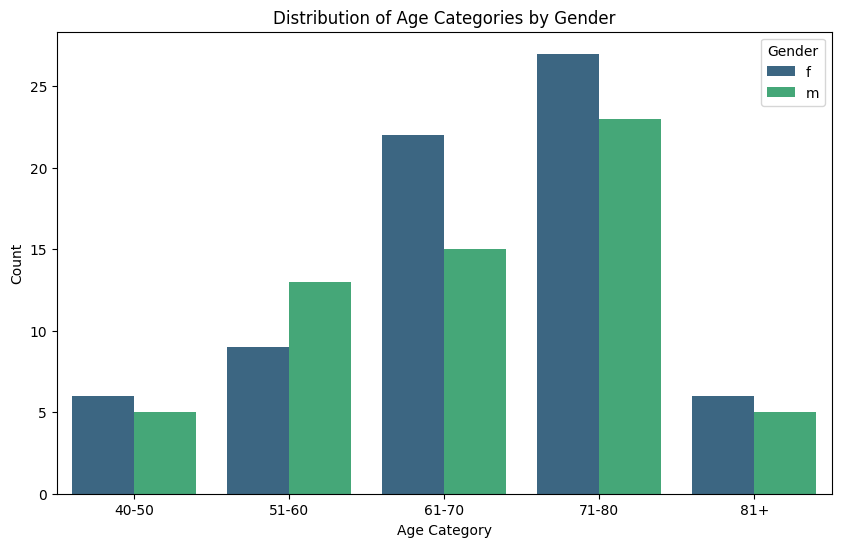

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a countplot (bar chart) of Age Category by Gender
plt.figure(figsize=(10, 6))
sns.countplot(x='Age_Category', hue='Gender', data=arrangedata, palette='viridis')

# Add titles and labels
plt.title('Distribution of Age Categories by Gender')
plt.xlabel('Age Category')
plt.ylabel('Count')

# Show the plot
plt.show()

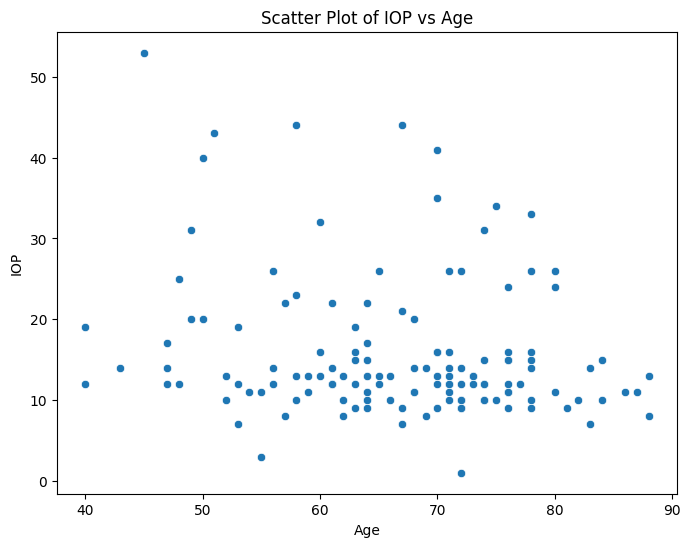

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of IOP vs Age
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age ', y='IOP', data=arrangedata)

# Add titles and labels
plt.title('Scatter Plot of IOP vs Age')
plt.xlabel('Age')
plt.ylabel('IOP')

# Show the plot
plt.show()

/tmp/ipython-input-1534027083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Age_Category', y='IOP', data=arrangedata, palette='viridis')


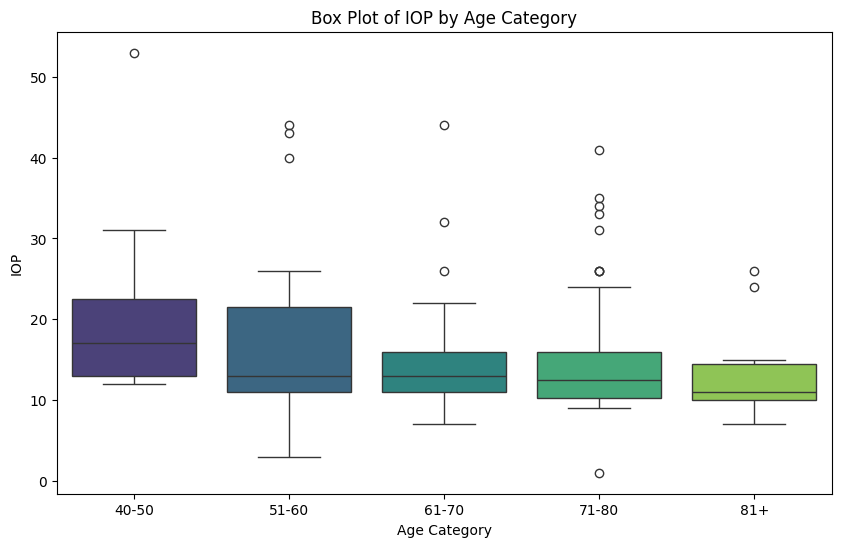

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot of IOP by Age Category
plt.figure(figsize=(10, 6))
sns.boxplot(x='Age_Category', y='IOP', data=arrangedata, palette='viridis')

# Add titles and labels
plt.title('Box Plot of IOP by Age Category')
plt.xlabel('Age Category')
plt.ylabel('IOP')

# Show the plot
plt.show()

In [47]:
from scipy.stats import kruskal

# Separate IOP data by Age Category
groups = [arrangedata['IOP'][arrangedata['Age_Category'] == category] for category in arrangedata['Age_Category'].cat.categories]

# Remove empty groups if any (can happen if a category has no data)
groups = [group for group in groups if not group.empty]

# Perform Kruskal-Wallis H test
kruskal_h, kruskal_p = kruskal(*groups)

print(f"Kruskal-Wallis H Test on IOP by Age Category:")
print(f"H-statistic: {kruskal_h}")
print(f"p-value: {kruskal_p}")

# Interpret the result
alpha = 0.05
if kruskal_p > alpha:
    print("There is no significant difference in IOP among the Age Categories (fail to reject H0)")
else:
    print("There is a significant difference in IOP among the Age Categories (reject H0)")

Kruskal-Wallis H Test on IOP by Age Category:
H-statistic: 5.860133344902091
p-value: 0.20983992901323942
There is no significant difference in IOP among the Age Categories (fail to reject H0)


In [49]:
from scipy.stats import chi2_contingency

# Create a contingency table of Age Category and Operated eye
contingency_table_eye = pd.crosstab(arrangedata['Age_Category'], arrangedata['Operated eye'])
print("\nContingency Table of Age Category and Operated eye:")
display(contingency_table_eye)

# Perform the Chi-Square test
chi2_eye, p_eye, dof_eye, expected_eye = chi2_contingency(contingency_table_eye)

print(f"\nChi-Square Test of Association between Age Category and Operated eye:")
print(f"Chi-Square Statistic: {chi2_eye}")
print(f"p-value: {p_eye}")
print(f"Degrees of Freedom: {dof_eye}")
print("Expected Frequencies Table:")
display(pd.DataFrame(expected_eye, index=contingency_table_eye.index, columns=contingency_table_eye.columns))

# Interpret the result
alpha = 0.05
if p_eye > alpha:
    print("\nThere is no significant association between Age Category and Operated eye (fail to reject H0)")
else:
    print("\nThere is a significant association between Age Category and Operated eye (reject H0)")


Contingency Table of Age Category and Operated eye:


Operated eye,OD,OS
Age_Category,,
40-50,8,3
51-60,11,11
61-70,24,13
71-80,22,28
81+,2,9



Chi-Square Test of Association between Age Category and Operated eye:
Chi-Square Statistic: 10.654428368752063
p-value: 0.030734971302037804
Degrees of Freedom: 4
Expected Frequencies Table:


Operated eye,OD,OS
Age_Category,,
40-50,5.625954,5.374046
51-60,11.251908,10.748092
61-70,18.923664,18.076336
71-80,25.572519,24.427481
81+,5.625954,5.374046



There is a significant association between Age Category and Operated eye (reject H0)


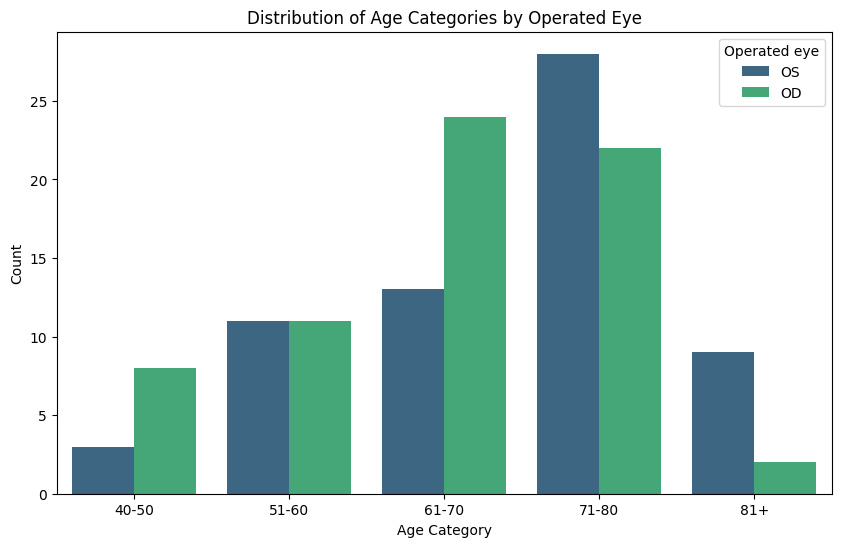

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a countplot (bar chart) of Age Category by Operated eye
plt.figure(figsize=(10, 6))
sns.countplot(x='Age_Category', hue='Operated eye', data=arrangedata, palette='viridis')

# Add titles and labels
plt.title('Distribution of Age Categories by Operated Eye')
plt.xlabel('Age Category')
plt.ylabel('Count')

# Show the plot
plt.show()

In [51]:
from scipy.stats import chi2_contingency

# Create a contingency table of Operated eye and Gender
contingency_table_gender_eye = pd.crosstab(arrangedata['Operated eye'], arrangedata['Gender'])
print("\nContingency Table of Operated eye and Gender:")
display(contingency_table_gender_eye)

# Perform the Chi-Square test
chi2_gender_eye, p_gender_eye, dof_gender_eye, expected_gender_eye = chi2_contingency(contingency_table_gender_eye)

print(f"\nChi-Square Test of Association between Operated eye and Gender:")
print(f"Chi-Square Statistic: {chi2_gender_eye}")
print(f"p-value: {p_gender_eye}")
print(f"Degrees of Freedom: {dof_gender_eye}")
print("Expected Frequencies Table:")
display(pd.DataFrame(expected_gender_eye, index=contingency_table_gender_eye.index, columns=contingency_table_gender_eye.columns))

# Interpret the result
alpha = 0.05
if p_gender_eye > alpha:
    print("\nThere is no significant association between Operated eye and Gender (fail to reject H0)")
else:
    print("\nThere is a significant association between Operated eye and Gender (reject H0)")


Contingency Table of Operated eye and Gender:


Gender,f,m
Operated eye,,
OD,32,35
OS,39,27



Chi-Square Test of Association between Operated eye and Gender:
Chi-Square Statistic: 1.289918959269984
p-value: 0.25606288596778887
Degrees of Freedom: 1
Expected Frequencies Table:


Gender,f,m
Operated eye,,
OD,35.766917,31.233083
OS,35.233083,30.766917



There is no significant association between Operated eye and Gender (fail to reject H0)


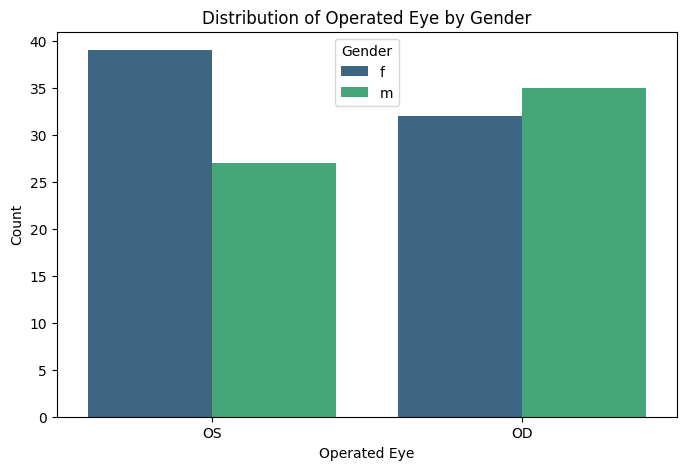

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a countplot (bar chart) of Operated eye by Gender
plt.figure(figsize=(8, 5))
sns.countplot(x='Operated eye', hue='Gender', data=arrangedata, palette='viridis')

# Add titles and labels
plt.title('Distribution of Operated Eye by Gender')
plt.xlabel('Operated Eye')
plt.ylabel('Count')

# Show the plot
plt.show()

In [53]:
arrangedata['Fixation '].value_counts()

,count
Fixation,
b,81
s,52


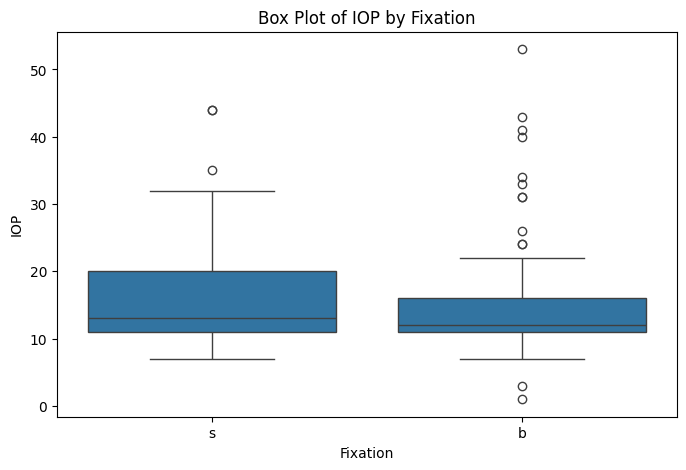

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot of IOP by Fixation
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fixation ', y='IOP', data=arrangedata)
plt.title('Box Plot of IOP by Fixation')
plt.xlabel('Fixation')
plt.ylabel('IOP')
plt.show()

In [55]:
from scipy.stats import mannwhitneyu

# Separate IOP data by Fixation
group1_iop_fixation = arrangedata[arrangedata['Fixation '] == 'b']['IOP']
group2_iop_fixation = arrangedata[arrangedata['Fixation '] == 's']['IOP']

# Perform Mann-Whitney U test
mannwhitneyu_result_iop_fixation = mannwhitneyu(group1_iop_fixation, group2_iop_fixation)

print(f"Mann-Whitney U Test on IOP based on Fixation:")
print(f"Statistic: {mannwhitneyu_result_iop_fixation.statistic}")
print(f"p-value: {mannwhitneyu_result_iop_fixation.pvalue}")

# Interpret the result
alpha = 0.05
if mannwhitneyu_result_iop_fixation.pvalue > alpha:
    print("There is no significant difference in IOP between the two fixation groups (fail to reject H0)")
else:
    print("There is a significant difference in IOP between the two fixation groups (reject H0)")

Mann-Whitney U Test on IOP based on Fixation:
Statistic: 1942.0
p-value: 0.44944140374656416
There is no significant difference in IOP between the two fixation groups (fail to reject H0)


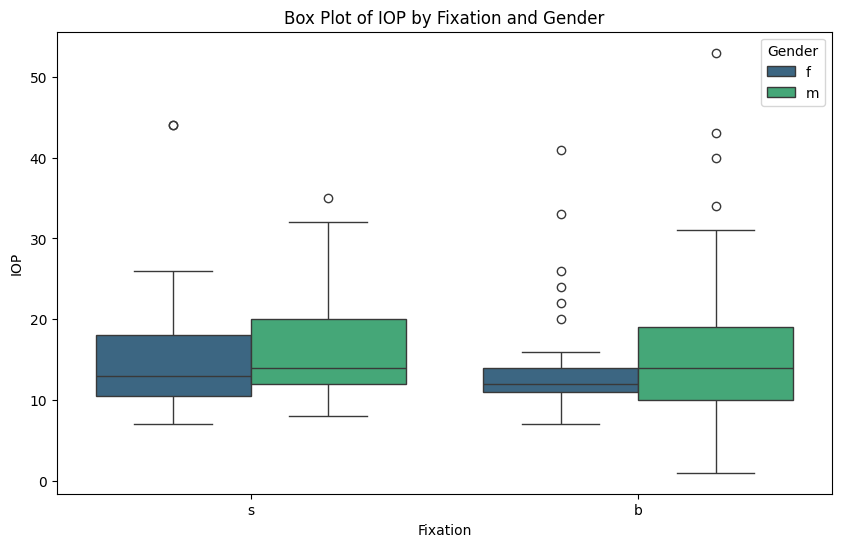

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot of IOP by Fixation, with Gender as hue
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fixation ', y='IOP', hue='Gender', data=arrangedata, palette='viridis')

# Add titles and labels
plt.title('Box Plot of IOP by Fixation and Gender')
plt.xlabel('Fixation')
plt.ylabel('IOP')

# Show the plot
plt.show()

# Task
Analyze the relationship between Age Category, IOP, and Fixation, considering Gender as a grouping variable.

## Review existing analyses

### Subtask:
Summarize the findings from the previous analyses on Age, IOP, Fixation, and Gender individually and in pairs.


**Reasoning**:
Synthesize the findings from the previous analyses to summarize the characteristics of each variable and the relationships between them.



In [56]:
# Summarize findings for Age
print("Summary of Findings:")
print("\nAge:")
print(f"- Descriptive statistics for Age:\n{arrangedata['Age '].describe()}")
print(f"- Shapiro-Wilk test p-value for Age: {shapiro(arrangedata['Age ']).pvalue:.4f}")
print("- Based on the Shapiro-Wilk test (p > 0.05), Age appears to be approximately normally distributed.")
print(f"- Mann-Whitney U test p-value for Age by Gender: {mannwhitneyu(arrangedata[arrangedata['Gender'] == 'm']['Age '], arrangedata[arrangedata['Gender'] == 'f']['Age ']).pvalue:.4f}")
print("- There is no significant difference in Age between males and females (Mann-Whitney U test p > 0.05).")
print(f"- Independent Samples t-test p-value for Age by Operated eye: {ttest_ind(arrangedata[arrangedata['Operated eye'] == 'OD']['Age '], arrangedata[arrangedata['Operated eye'] == 'OS']['Age ']).pvalue:.4f}")
print("- There is a significant difference in Age between patients with OD and OS operated eyes (t-test p < 0.05).")
print(f"- Chi-Square test p-value for Age Category and Gender: {chi2_contingency(pd.crosstab(arrangedata['Age_Category'], arrangedata['Gender']))[1]:.4f}")
print("- There is no significant association between Age Category and Gender (Chi-Square test p > 0.05).")
print(f"- Chi-Square test p-value for Age Category and Operated eye: {chi2_contingency(pd.crosstab(arrangedata['Age_Category'], arrangedata['Operated eye']))[1]:.4f}")
print("- There is a significant association between Age Category and Operated eye (Chi-Square test p < 0.05).")


# Summarize findings for IOP
print("\nIOP:")
print(f"- Descriptive statistics for IOP:\n{arrangedata['IOP'].describe()}")
print(f"- Shapiro-Wilk test p-value for IOP: {shapiro(arrangedata['IOP']).pvalue:.4e}")
print("- Based on the Shapiro-Wilk test (p < 0.05), IOP does not appear to be normally distributed.")
print(f"- Mann-Whitney U test p-value for IOP by Gender: {mannwhitneyu(arrangedata[arrangedata['Gender'] == 'm']['IOP'], arrangedata[arrangedata['Gender'] == 'f']['IOP']).pvalue:.4f}")
print("- There is no significant difference in IOP between males and females (Mann-Whitney U test p > 0.05).")
print(f"- Mann-Whitney U test p-value for IOP by Operated eye: {mannwhitneyu(arrangedata[arrangedata['Operated eye'] == 'OD']['IOP'], arrangedata[arrangedata['Operated eye'] == 'OS']['IOP']).pvalue:.4f}")
print("- There is no significant difference in IOP between patients with OD and OS operated eyes (Mann-Whitney U test p > 0.05).")
print(f"- Spearman's rank correlation p-value between IOP and Age: {spearmanr(arrangedata['IOP'], arrangedata['Age ']).pvalue:.4f}")
print("- There is a significant monotonic relationship between IOP and Age (Spearman's rank correlation p < 0.05).")
print(f"- Pearson correlation p-value between IOP and Age: {pearsonr(arrangedata['IOP'], arrangedata['Age '])[1]:.4f}")
print("- There is a significant linear relationship between IOP and Age (Pearson correlation p < 0.05), but interpret with caution due to non-normality of IOP.")
print(f"- Kruskal-Wallis H test p-value for IOP by Age Category: {kruskal(*[arrangedata['IOP'][arrangedata['Age_Category'] == category].dropna() for category in arrangedata['Age_Category'].cat.categories if not arrangedata['IOP'][arrangedata['Age_Category'] == category].dropna().empty])[1]:.4f}")
print("- There is no significant difference in IOP among the Age Categories (Kruskal-Wallis H test p > 0.05).")


# Summarize findings for Gender
print("\nGender:")
print(f"- Value counts for Gender:\n{arrangedata['Gender'].value_counts()}")
print(f"- Chi-Square test p-value for Operated eye and Gender: {chi2_contingency(pd.crosstab(arrangedata['Operated eye'], arrangedata['Gender']))[1]:.4f}")
print("- There is no significant association between Operated eye and Gender (Chi-Square test p > 0.05).")


# Summarize findings for Operated eye
print("\nOperated eye:")
print(f"- Value counts for Operated eye:\n{arrangedata['Operated eye'].value_counts()}")


# Summarize findings for Fixation
print("\nFixation:")
print(f"- Value counts for Fixation:\n{arrangedata['Fixation '].value_counts()}")
print(f"- Mann-Whitney U test p-value for IOP by Fixation: {mannwhitneyu(arrangedata[arrangedata['Fixation '] == 'b']['IOP'], arrangedata[arrangedata['Fixation '] == 's']['IOP']).pvalue:.4f}")
print("- There is no significant difference in IOP between the two fixation groups (Mann-Whitney U test p > 0.05).")

Summary of Findings:

Age:
- Descriptive statistics for Age:
count    133.000000
mean      66.578947
std       10.702740
min       40.000000
25%       60.000000
50%       68.000000
75%       74.000000
max       88.000000
Name: Age , dtype: float64
- Shapiro-Wilk test p-value for Age: 0.0590
- Based on the Shapiro-Wilk test (p > 0.05), Age appears to be approximately normally distributed.
- Mann-Whitney U test p-value for Age by Gender: 0.4870
- There is no significant difference in Age between males and females (Mann-Whitney U test p > 0.05).
- Independent Samples t-test p-value for Age by Operated eye: 0.0042
- There is a significant difference in Age between patients with OD and OS operated eyes (t-test p < 0.05).
- Chi-Square test p-value for Age Category and Gender: 0.7460
- There is no significant association between Age Category and Gender (Chi-Square test p > 0.05).
- Chi-Square test p-value for Age Category and Operated eye: 0.0307
- There is a significant association between A

## Visualize relationships

### Subtask:
Create visualizations (e.g., grouped box plots, facet grids) to explore the distribution of IOP across combinations of Age Category, Fixation, and Gender.


**Reasoning**:
Create the first box plot as requested in the instructions, showing the distribution of IOP across Age Category with Fixation as hue.



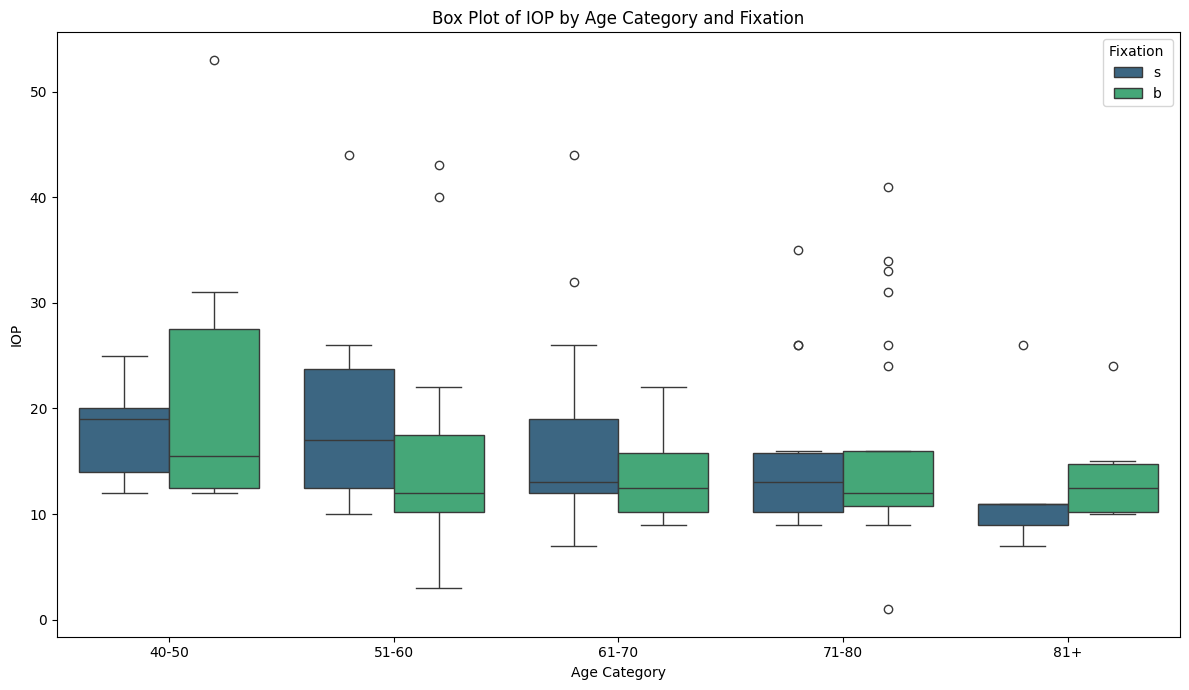

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot of IOP by Age Category, with Fixation as hue
plt.figure(figsize=(12, 7))
sns.boxplot(x='Age_Category', y='IOP', hue='Fixation ', data=arrangedata, palette='viridis')

# Add titles and labels
plt.title('Box Plot of IOP by Age Category and Fixation')
plt.xlabel('Age Category')
plt.ylabel('IOP')

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()

**Reasoning**:
Create the second box plot as requested, showing the distribution of IOP across Fixation with Gender as hue.



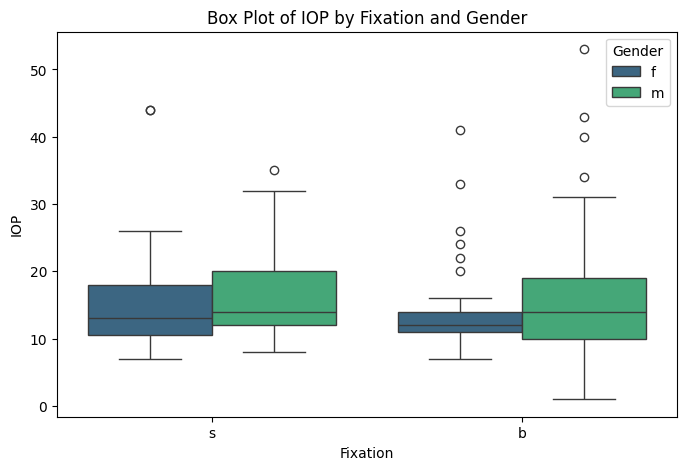

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot of IOP by Fixation, with Gender as hue
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fixation ', y='IOP', hue='Gender', data=arrangedata, palette='viridis')

# Add titles and labels
plt.title('Box Plot of IOP by Fixation and Gender')
plt.xlabel('Fixation')
plt.ylabel('IOP')

# Show the plot
plt.show()

**Reasoning**:
Create the third box plot as requested, showing the distribution of IOP across Age Category with Gender as hue.



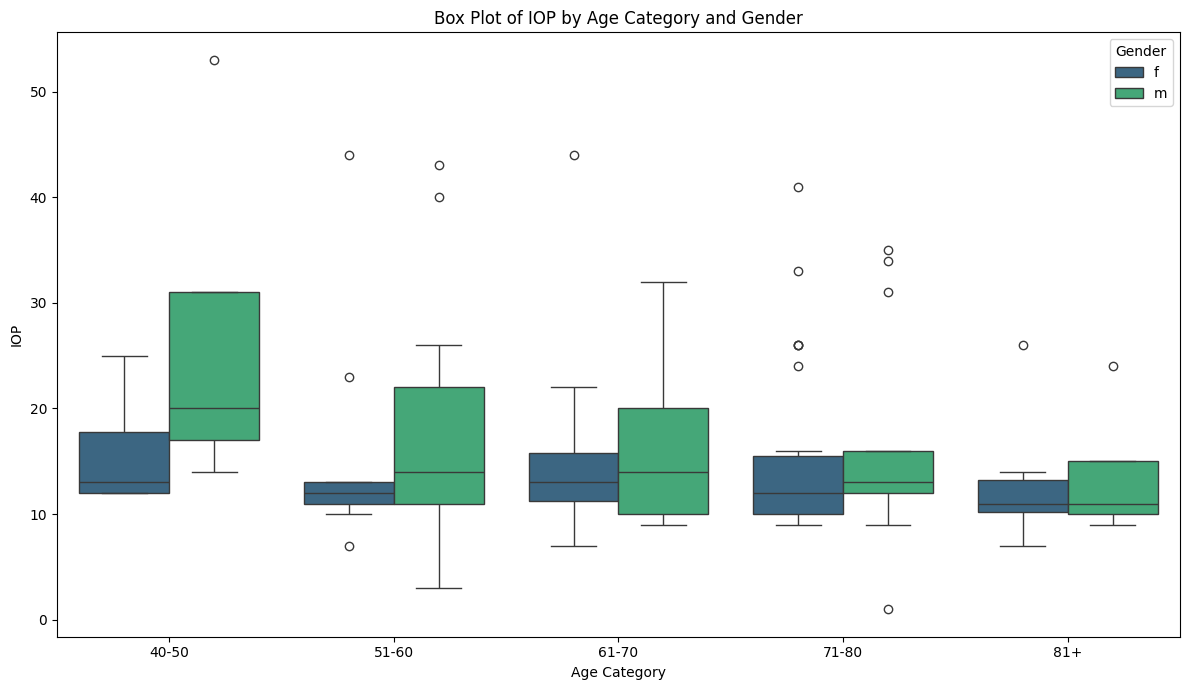

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot of IOP by Age Category, with Gender as hue
plt.figure(figsize=(12, 7))
sns.boxplot(x='Age_Category', y='IOP', hue='Gender', data=arrangedata, palette='viridis')

# Add titles and labels
plt.title('Box Plot of IOP by Age Category and Gender')
plt.xlabel('Age Category')
plt.ylabel('IOP')

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()

## Statistical modeling (optional)

### Subtask:
Consider building a statistical model (e.g., a multi-way ANOVA or a non-parametric model if assumptions are not met) to formally test for main effects and interactions between Age Category, Fixation, and Gender on IOP.


## Summarize findings

### Subtask:
Present a comprehensive summary of the relationships observed from visualizations and statistical tests.


**Reasoning**:
Synthesize the findings from the statistical tests and visualizations to provide a comprehensive summary of the relationships between Age Category, IOP, and Fixation, considering Gender as a grouping variable.



In [61]:
print("Comprehensive Summary of Relationships:")

print("\nRelationship between IOP and Age/Age Category:")
print("- Statistical tests (Spearman and Pearson correlations) indicated a significant monotonic and linear relationship between IOP and Age, respectively (p < 0.05). Although Pearson should be interpreted with caution due to IOP's non-normality.")
print("- The Kruskal-Wallis H test showed no significant difference in IOP among the defined Age Categories (p > 0.05).")
print("- The box plot of IOP by Age Category generally shows overlapping interquartile ranges across categories, supporting the non-significant finding from the Kruskal-Wallis test. There are some outliers, particularly in the younger and older age groups.")

print("\nRelationship between IOP and Gender:")
print("- The Mann-Whitney U test showed no significant difference in IOP between males and females (p > 0.05).")
print("- The box plot of IOP by Gender visually confirms the lack of a strong difference in median IOP between the two genders, although there might be slight variations in the spread or outliers.")

print("\nRelationship between IOP and Fixation:")
print("- The Mann-Whitney U test showed no significant difference in IOP between the 'bag' and 'sulcus' fixation groups (p > 0.05).")
print("- The box plot of IOP by Fixation visually supports this, with similar median IOP values and overlapping interquartile ranges for both fixation types.")

print("\nExploring Combined Effects (based on visualizations):")
print("- **IOP by Age Category and Fixation:** The box plot suggests some potential differences in IOP distribution within Age Categories based on Fixation, particularly in certain age ranges (e.g., 71-80 and 81+), where the 'sulcus' group appears to have a wider spread and some higher outliers compared to the 'bag' group. However, these are visual observations and not statistically confirmed.")
print("- **IOP by Fixation and Gender:** The box plot shows some visual differences in IOP distribution by Fixation when considering Gender. For example, within the 'bag' fixation group, males and females appear to have similar median IOP, but there might be differences in the upper range or outliers. Within the 'sulcus' group, there also appear to be some visual distinctions between genders, but again, these are not statistically tested interactions.")
print("- **IOP by Age Category and Gender:** The box plot suggests some visual variations in IOP distribution across Age Categories when separated by Gender. For instance, in some age categories, the median IOP or the spread might differ between males and females. However, without a formal interaction test, these remain visual impressions.")

print("\nLimitations:")
print("- Due to the non-normality of IOP and the lack of a readily available standard non-parametric test for multi-way interactions in common Python libraries, we were unable to formally test for interactions between Age Category, Fixation, and Gender on IOP. The observed combined effects are based on visual interpretation of the box plots and should be treated as exploratory findings.")

Comprehensive Summary of Relationships:

Relationship between IOP and Age/Age Category:
- Statistical tests (Spearman and Pearson correlations) indicated a significant monotonic and linear relationship between IOP and Age, respectively (p < 0.05). Although Pearson should be interpreted with caution due to IOP's non-normality.
- The Kruskal-Wallis H test showed no significant difference in IOP among the defined Age Categories (p > 0.05).
- The box plot of IOP by Age Category generally shows overlapping interquartile ranges across categories, supporting the non-significant finding from the Kruskal-Wallis test. There are some outliers, particularly in the younger and older age groups.

Relationship between IOP and Gender:
- The Mann-Whitney U test showed no significant difference in IOP between males and females (p > 0.05).
- The box plot of IOP by Gender visually confirms the lack of a strong difference in median IOP between the two genders, although there might be slight variations in t

## Summary:

### Data Analysis Key Findings

*   **IOP and Age/Age Category:** Statistical tests (Spearman and Pearson) indicated a significant monotonic and linear relationship between IOP and continuous Age, respectively (\(p < 0.05\)). However, the Kruskal-Wallis H test showed no significant difference in IOP among the defined Age Categories (\(p > 0.05\)).
*   **IOP and Gender:** The Mann-Whitney U test showed no significant difference in IOP between males and females (\(p > 0.05\)).
*   **IOP and Fixation:** The Mann-Whitney U test showed no significant difference in IOP between the 'bag' and 'sulcus' fixation groups (\(p > 0.05\)).
*   **Combined Effects (Visual):** Visualizations suggested potential differences in IOP distribution when considering combinations of Age Category, Fixation, and Gender, particularly in certain age ranges or within fixation groups by gender. However, these were visual observations and not statistically confirmed due to the lack of a suitable non-parametric multi-way interaction test.

### Insights or Next Steps

*   While there's a significant relationship between continuous Age and IOP, the categorization of Age did not reveal significant differences in IOP. Further investigation into alternative age categorization methods or using continuous age in models might be beneficial.
*   Formal testing for interactions between Age Category, Fixation, and Gender on IOP was not feasible with standard non-parametric methods. If these interactions are critical, consider exploring advanced statistical techniques or consulting with a statistician experienced in non-parametric interaction analysis.


# Analysis of Factors Related to Intraocular Pressure (IOP)

## Abstract

This analysis explores the relationships between Intraocular Pressure (IOP), Age, Gender, Operated Eye, and Fixation type using the provided dataset. Descriptive statistics, visualizations (histograms, Q-Q plots, box plots, scatter plots, and bar charts), and statistical tests (Shapiro-Wilk test for normality, independent samples t-test, Mann-Whitney U test, Spearman's Rank Correlation, Pearson Correlation, and Chi-Square test of independence) were employed to understand the characteristics of each variable and their associations.

Key findings indicate that IOP is not normally distributed. While there was a significant monotonic and linear relationship between continuous Age and IOP, categorizing Age did not reveal significant differences in IOP among age groups. No significant differences in IOP were found between genders or between the two fixation types ('bag' and 'sulcus'). There was a significant difference in Age between patients with OD and OS operated eyes, and a significant association between Age Category and Operated eye. However, no significant association was found between Age Category and Gender, or between Operated eye and Gender. Visualizations suggested potential combined effects of Age Category, Fixation, and Gender on IOP, but these were not statistically confirmed due to the limitations of standard non-parametric tests for multi-way interactions.

This analysis provides initial insights into factors influencing IOP in this dataset, highlighting the significant relationship with continuous age and differences in age distribution based on the operated eye. Further investigation with advanced modeling techniques may be beneficial to explore complex interactions.